## TASK 1

In [13]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

"""Dataset uploaded to Colab, but needs to be uploaded every time, OUTSIDE the root folder"""

'Dataset uploaded to Colab, but needs to be uploaded every time'

## TASK 2

In [14]:
df = pd.read_csv("loan_approval_dataset.csv", sep=";") # Csv placed OUTSIDE the root directory in the Colab "Files" section.

# Clean dataset of leading and ending whitespaces.
df.columns = df.columns.str.strip() # Column names.
df = df.apply(lambda column: column.str.strip() if column.dtype == "object" else column) # Entries.

print(df.head(20).to_string(index=False)) # index=False since we already have load_id, no need to display row id too.


 loan_id  no_of_dependents    education self_employed  income_annum  loan_amount  loan_term  cibil_score  residential_assets_value  commercial_assets_value  luxury_assets_value  bank_asset_value loan_status
       1                 2     Graduate            No       9600000     29900000         12          778                   2400000                 17600000             22700000           8000000    Approved
       2                 0 Not Graduate           Yes       4100000     12200000          8          417                   2700000                  2200000              8800000           3300000    Rejected
       3                 3     Graduate            No       9100000     29700000         20          506                   7100000                  4500000             33300000          12800000    Rejected
       4                 3     Graduate            No       8200000     30700000          8          467                  18200000                  3300000             2330

## TASK 3

In [15]:
feature_table = pd.DataFrame({ # Manual feature table.
    "Feature": [
        "loan_id",
        "no_of_dependents",
        "education",
        "self_employed",
        "income_annum",
        "loan_amount",
        "loan_term",
        "cibil_score",
        "residential_assets_value",
        "commercial_assets_value",
        "luxury_assets_value",
        "bank_asset_value"
    ],

    # Manually assess in which category each feature belongs to.
    "Important": [
        0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1
    ],

    "In-between": [
        0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0
    ],

    "Not-important": [
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ]

    # As we do not need the reasoning for the heatmap, I included it in the report to reduce clutter in the code.
})

## TASK 4

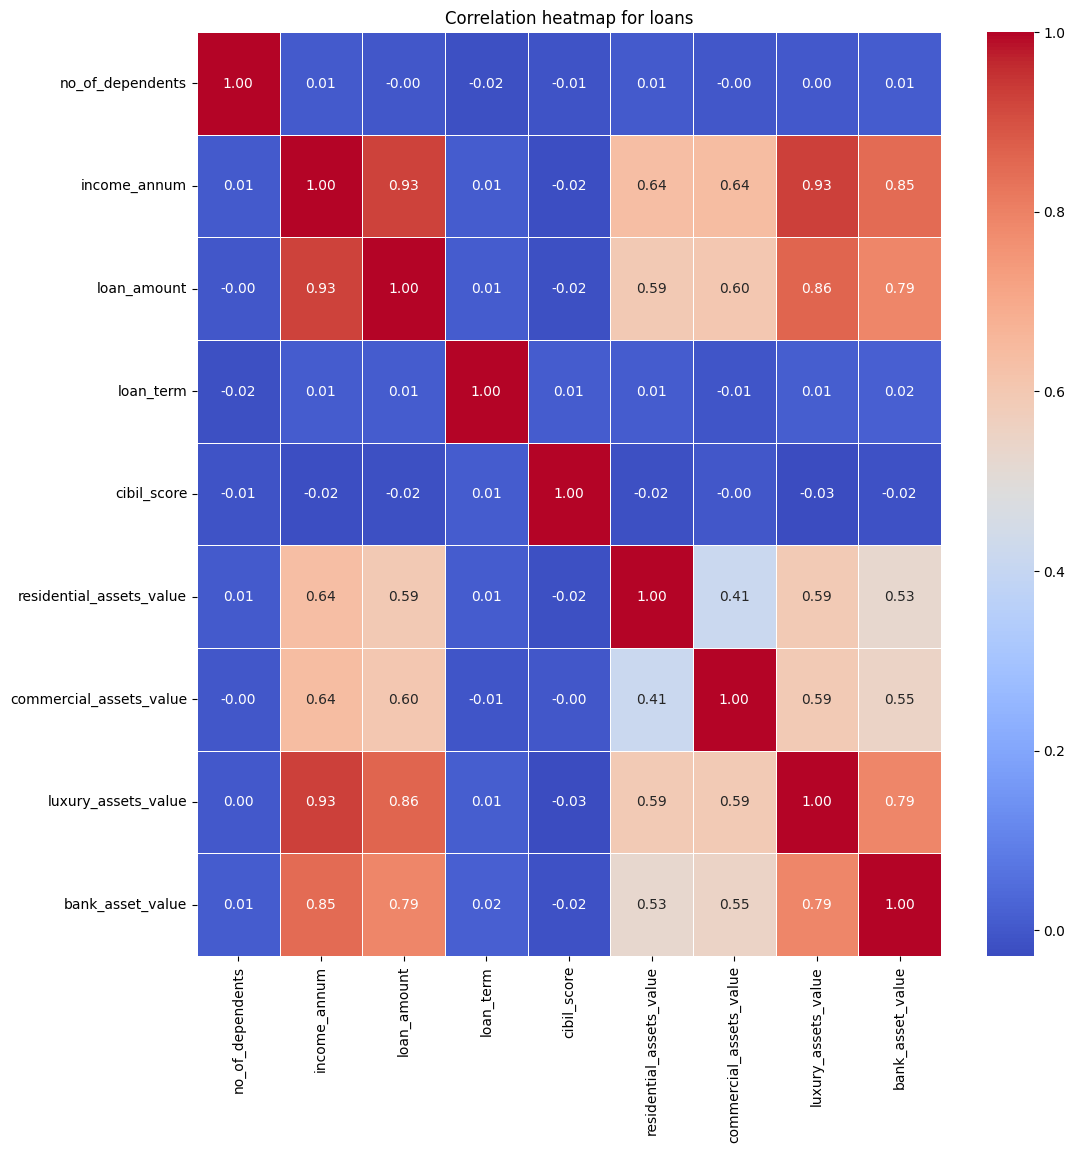

In [16]:
selected_features = feature_table.loc[feature_table["Not-important"] == 0, "Feature"].tolist() # Exclude any feature that is not important.
numeric_df = df[selected_features].select_dtypes(include=np.number) # Get only numeric features.

# Calculate the correlation matrix and create the heatmap.
corrmatrix = numeric_df.corr()
plt.figure(figsize=(12, 12))

# Plot the heatmap.
sns.heatmap(corrmatrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5) #I found these values online.

plt.title("Correlation heatmap for loans")
plt.show()

## TASK 5

In [17]:
df["loan_status_numeric"] = df["loan_status"].map({"Approved": 1, "Rejected": 0}) # Convert loan status to numeric.

# Calculate correlations.
status_corr = df[numeric_df.columns.tolist() + ["loan_status_numeric"]].corr()
print("Correlational data:")
print(status_corr["loan_status_numeric"].sort_values(ascending=False))

print("-----------------")

# Education categorical feature.
education_status = pd.crosstab(df["education"], df["loan_status"], normalize="index") * 100
print(education_status)

Correlational data:
loan_status_numeric         1.000000
cibil_score                 0.770518
loan_amount                 0.016150
commercial_assets_value     0.008246
bank_asset_value           -0.006778
residential_assets_value   -0.014367
income_annum               -0.015189
luxury_assets_value        -0.015465
no_of_dependents           -0.018114
loan_term                  -0.113036
Name: loan_status_numeric, dtype: float64
-----------------
loan_status    Approved   Rejected
education                         
Graduate      62.453358  37.546642
Not Graduate  61.976471  38.023529
